In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
titanic = sns.load_dataset("titanic")

print("Dataset Shape:", titanic.shape)

titanic.head()

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.info()

titanic.describe()

titanic["survived"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [4]:
# Percentage of missing values

missing_percent = (titanic.isnull().sum() / len(titanic)) * 100

missing_percent = missing_percent[missing_percent > 0]

print(missing_percent.round(1).sort_values(ascending=False))

deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64


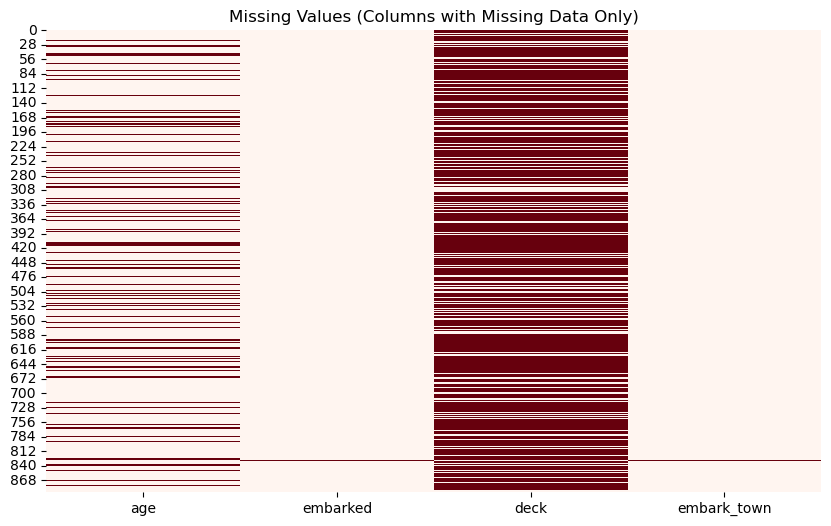

In [5]:
missing_cols = titanic.columns[titanic.isnull().any()]

plt.figure(figsize=(10,6))

sns.heatmap(
    titanic[missing_cols].isnull(),
    cbar=False,
    cmap="Reds"
)

plt.title("Missing Values (Columns with Missing Data Only)")

plt.show()

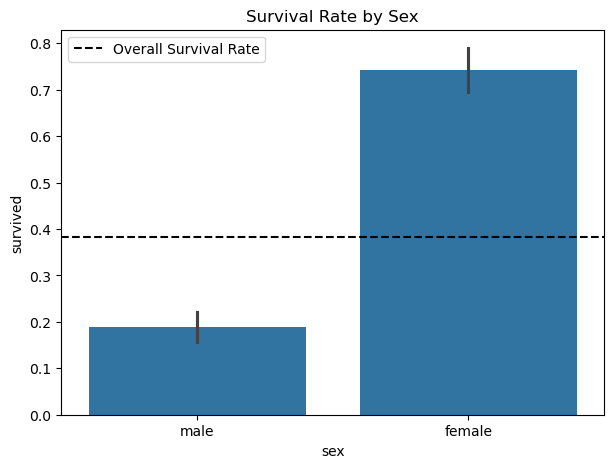

In [6]:
plt.figure(figsize=(7,5))

sns.barplot(data=titanic, x="sex", y="survived")

plt.axhline(
    titanic["survived"].mean(),
    color="black",
    linestyle="--",
    label="Overall Survival Rate"
)

plt.legend()

plt.title("Survival Rate by Sex")

plt.show()

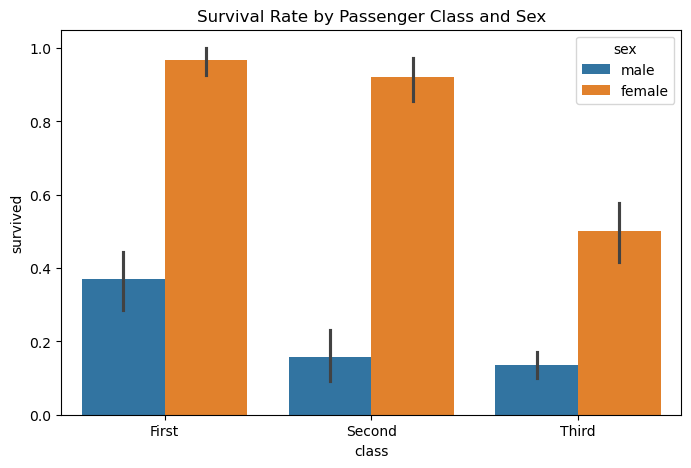

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=titanic,
    x="class",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")

plt.show()

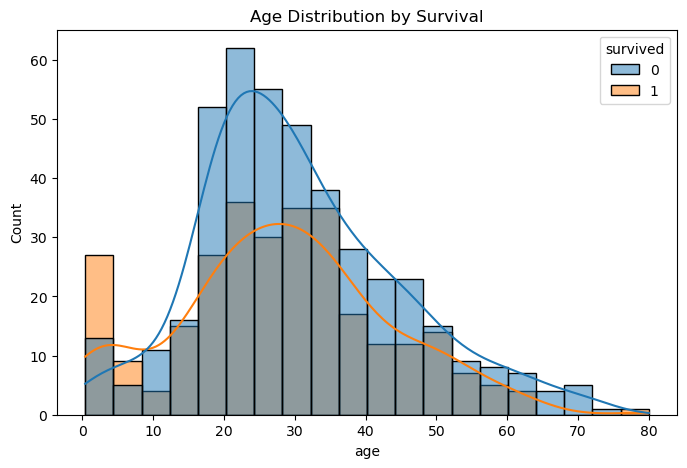

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=titanic,
    x="age",
    hue="survived",
    kde=True
)

plt.title("Age Distribution by Survival")

plt.show()

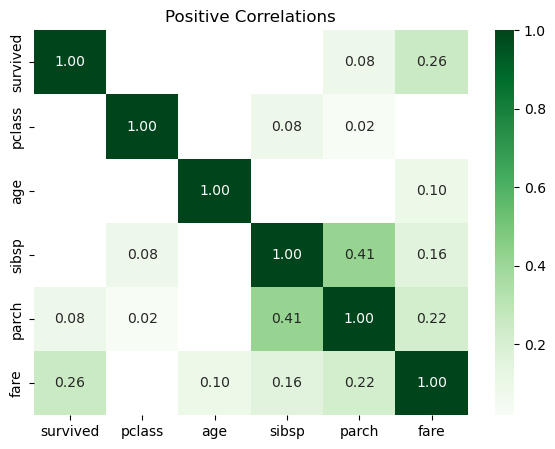

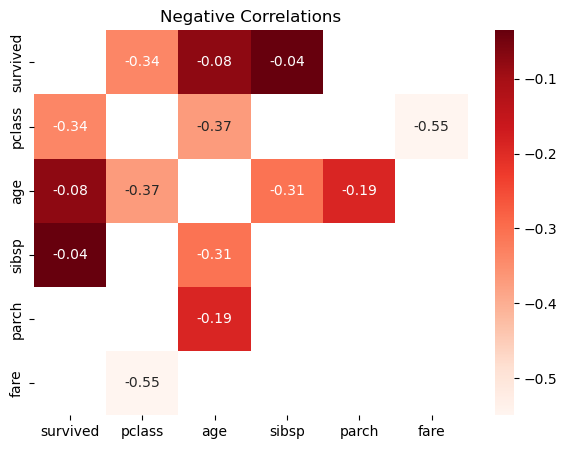

In [9]:
cols = ["survived","pclass","age","sibsp","parch","fare"]

corr = titanic[cols].corr()

# Positive Correlations

plt.figure(figsize=(7,5))

sns.heatmap(
    corr.where(corr > 0),
    annot=True,
    cmap="Greens",
    fmt=".2f"
)

plt.title("Positive Correlations")

plt.show()

# Negative Correlations

plt.figure(figsize=(7,5))

sns.heatmap(
    corr.where(corr < 0),
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Negative Correlations")

plt.show()

In [11]:
def titanic_eda_report(df, path="titanic_eda_report.pdf"):

    pdf = PdfPages(path)

    # Page 1 - Missing Value Heatmap (TODO 2)
    missing_cols = df.columns[df.isnull().any()]

    plt.figure(figsize=(11,6))
    sns.heatmap(
        df[missing_cols].isnull(),
        cbar=False,
        cmap="Reds"
    )
    plt.title("Page 1 - Missing Values")
    pdf.savefig()
    plt.close()

    # Page 2 - Survival by Sex (TODO 3)
    plt.figure(figsize=(11,6))
    sns.barplot(data=df, x="sex", y="survived")

    plt.axhline(
        df["survived"].mean(),
        color="black",
        linestyle="--",
        label="Overall Survival Rate"
    )

    plt.legend()
    plt.title("Page 2 - Survival Rate by Sex")
    pdf.savefig()
    plt.close()

    # Page 3 - Survival by Class and Sex (TODO 4)
    plt.figure(figsize=(11,6))
    sns.barplot(
        data=df,
        x="class",
        y="survived",
        hue="sex"
    )

    plt.title("Page 3 - Survival by Class and Sex")
    pdf.savefig()
    plt.close()

    # Page 4 - Positive Correlation Heatmap (TODO 5)
    cols = ["survived","pclass","age","sibsp","parch","fare"]

    corr = df[cols].corr()

    plt.figure(figsize=(11,6))
    sns.heatmap(
        corr.where(corr > 0),
        annot=True,
        fmt=".2f",
        cmap="Greens",
        vmin=0
    )

    plt.title("Page 4 - Positive Correlations")
    pdf.savefig()
    plt.close()

    # Page 5 - Negative Correlation Heatmap (TODO 5)

    plt.figure(figsize=(11,6))
    sns.heatmap(
        corr.where(corr < 0),
        annot=True,
        fmt=".2f",
        cmap="Reds",
        vmax=0
    )

    plt.title("Page 5 - Negative Correlations")
    pdf.savefig()
    plt.close()

    pdf.close()

    print("Report written to", path)


titanic_eda_report(titanic)

Report written to titanic_eda_report.pdf
